In [ ]:
import jax.numpy as jnp
import jax

alpha = 0.1
beta = 0.3
k = 10
OP_key = jax.random.PRNGKey(0)

def log_p_cond(i, j, x, xij):
  r"""
    Given cell (i,j), evaluate
      log p(x_{i,j}=xij \given x_{-(i,j)} = x_{-(i,j)})
    where the second x_{-(i,j)} stands for the values associated to coordinates of x except (i,j)
  """

  cross_terms = (xij==x[i,j-1])+(xij==x[i,j+1])+(xij==x[i+1,j])+(xij==x[i-1,j]) # numbers of neighbours with same value as xij
  logp = alpha * xij + beta*cross_terms
  logp_opposite = alpha * (1-xij) + beta * (4-cross_terms)
  maxlogp = jax.lax.max(logp, logp_opposite)
  logp = logp-maxlogp - jnp.log(jnp.exp(logp-maxlogp)+jnp.exp(logp_opposite-maxlogp))
  return logp

def gibbs_ising(key, num_samples):
  seqs = jnp.zeros(shape=(num_samples, k, k), dtype=bool)
  key, subkey = jax.random.split(key)
  seq_init = jax.random.bernoulli(subkey, p=0.5, shape=(k,k)) # initialisation
  seqs = seqs.at[0].set(seq_init) # initialisation
  log_unifs = jnp.log(jax.random.uniform(key, shape=(num_samples, k, k))) # only randomness, apart from the initialisation
  def body(i, seqs):
    x = seqs.at[i-1].get()
    def row_body(row, x):
      def col_body(col, x):
        logp = log_p_cond(row, col, x, 1)
        logU = log_unifs.at[i, row, col].get()
        chosen_xij = jax.lax.cond(logU <= logp, lambda _: 1, lambda _: 0, None) # x_{i,j} sim p(x_{i,j} given x_{-(i,j)})
        x = x.at[row, col].set(chosen_xij) #updating on-line the cell
        return x
      x = jax.lax.fori_loop(0, k, col_body, x) # for each row, updating each col.
      return x
    x = jax.lax.fori_loop(0, k, row_body, x) # running the update for each row (and col)
    seqs = seqs.at[i].set(x) # updating my sequence of grids
    return seqs
  seqs = jax.lax.fori_loop(1, num_samples, body, seqs) # running my gibbs sampler over num_samples repetitions
  return seqs


In [ ]:
num_samples = 100
grids = gibbs_ising(OP_key, num_samples)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os

def grids_to_gif(grids, gif_path="animation.gif", fps=2):
    """
    grids: list or array of shape (N, k, k) with values 0 or 1
    gif_path: output file
    fps: frames per second
    """
    temp_files = []

    for i, grid in enumerate(grids):
        plt.figure(figsize=(4, 4))
        plt.imshow(grid, cmap="gray_r", vmin=0, vmax=1)
        plt.axis("off")

        filename = f"_frame_{i}.png"
        plt.savefig(filename, bbox_inches='tight', pad_inches=0)
        plt.close()

        temp_files.append(filename)

    # Create GIF
    with imageio.get_writer(gif_path, mode="I", fps=fps) as writer:
        for filename in temp_files:
            image = imageio.imread(filename)
            writer.append_data(image)

    # Cleanup temp files
    for filename in temp_files:
        os.remove(filename)

    print(f"GIF saved as {gif_path}")

grids_to_gif(grids)

/tmp/ipykernel_3479/4170378781.py:28: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


GIF saved as animation.gif


In [ ]:
number_of_gibbs = 1
my_keys = jax.random.split(OP_key, number_of_gibbs)
vmapped_gibbs = jax.vmap(lambda key : gibbs_ising(key, num_samples))

res = vmapped_gibbs(my_keys)

In [ ]:
my_statistic = jnp.sum(res, axis=[-1, -2])/(k**2)

In [ ]:
means = jnp.mean(my_statistic, axis=0)
vars = jnp.var(my_statistic, axis=0)

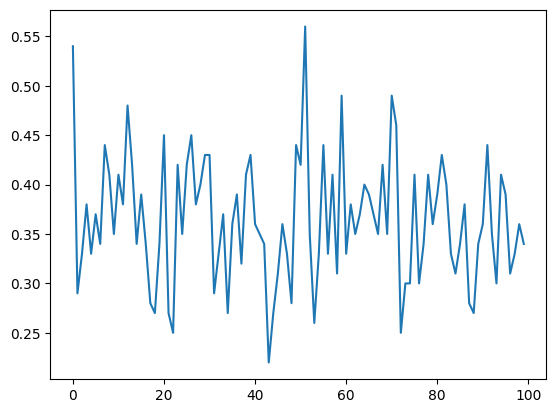

In [ ]:
plt.plot(means)

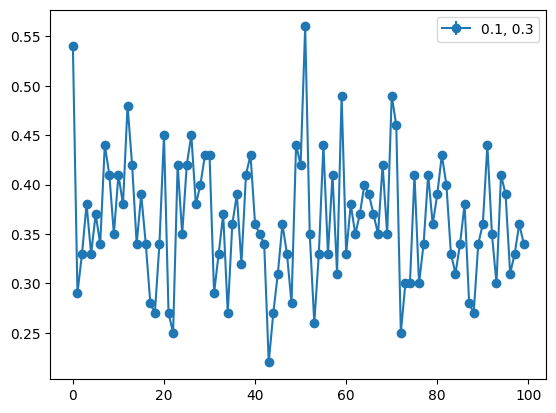

In [ ]:
plt.errorbar(jnp.arange(100), means, yerr=np.sqrt(vars), fmt='-o', label=f'{alpha}, {beta}')
plt.legend()

In [ ]:
vars.shape

(100,)

In [ ]:
alpha, beta

(0.2, 0.5)